In [99]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from pathlib import Path

from PIL import Image
import os

from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights

from collections import Counter
import hashlib

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

from sklearn.metrics import (
    classification_report,
    f1_score
)

In [100]:
def file_hash(path):

    ## Return hashed library for image leakage between training and testing sets
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


In [101]:
def collect_image_hashes(folder, dataset_name):
    ## Create the image hashes to see image leakage between training and testing sets

    records = []

    for path in Path(folder).rglob("*"):

        if path.is_file():
            records.append({
                "dataset": dataset_name,
                "class": path.parent.name,
                "filename": path.name,
                "path": str(path),
                "hash": file_hash(path)
            })

    return records

In [102]:
## Load pre-trained weights from ResNet18 convolutional neural network

weights = ResNet18_Weights.DEFAULT

# Name for transformations needed for the images to be processed
transform = weights.transforms()

# Loading and saving training and testing datasets as separated in images folder
train_dataset = ImageFolder("images/training", transform=transform)
test_dataset = ImageFolder("images/testing", transform=transform)

# Records in terms of hashes for the training image set
train_records = collect_image_hashes(
    "images/training",
    "training"
)

# Records in terms of hashes for the testing image set
test_records = collect_image_hashes(
    "images/testing",
    "testing"
)

# Dataframe appending both records
hash_df = pd.DataFrame(train_records + test_records)


In [103]:
# Splits the training set randomly into batches of 32 images while training and testing

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)

test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

# Counts how many total images we're working with, to view any imbalance

print(Counter(train_dataset.targets))
print(train_dataset.class_to_idx)
# A flip is characterized as 0 and notflip is 1.
# It is, largely, equally balanced with flip and notflip images (1162:1230)


Counter({1: 1230, 0: 1162})
{'flip': 0, 'notflip': 1}


In [104]:
# Initialize records to compare hashes
records = []

for classification in ["flip", "notflip"]:

    # Ensures to load images from each classification
    folder = f"images/training/{classification}"

    for filename in os.listdir(folder):

        # Combines file name with folder to get full path
        path = os.path.join(folder, filename)

        try:
            img = Image.open(path)

            # Keeps classification, filename, width, height and color/pixel mode.            
            records.append({"class": classification,
                "filename": filename,
                "width": img.width,
                "height": img.height,
                "mode": img.mode})

        except Exception:
            print("Could not open:", path)

# Creates dataframe of records
df = pd.DataFrame(records)

In [105]:
# Shows makeup of dataframe.
print(df.head())

# Standard deviation for height and width are both 0, so, all the dimensions are consistent.
print(df[["width", "height"]].describe())

# How many total colors/pixel formattings there are, of which there are 2392. Thus, all images are unique. 
print(df["mode"].value_counts())

  class            filename  width  height mode
0  flip  0001_000000010.jpg   1080    1920  RGB
1  flip  0001_000000011.jpg   1080    1920  RGB
2  flip  0001_000000012.jpg   1080    1920  RGB
3  flip  0001_000000013.jpg   1080    1920  RGB
4  flip  0001_000000014.jpg   1080    1920  RGB
        width  height
count  2392.0  2392.0
mean   1080.0  1920.0
std       0.0     0.0
min    1080.0  1920.0
25%    1080.0  1920.0
50%    1080.0  1920.0
75%    1080.0  1920.0
max    1080.0  1920.0
mode
RGB    2392
Name: count, dtype: int64


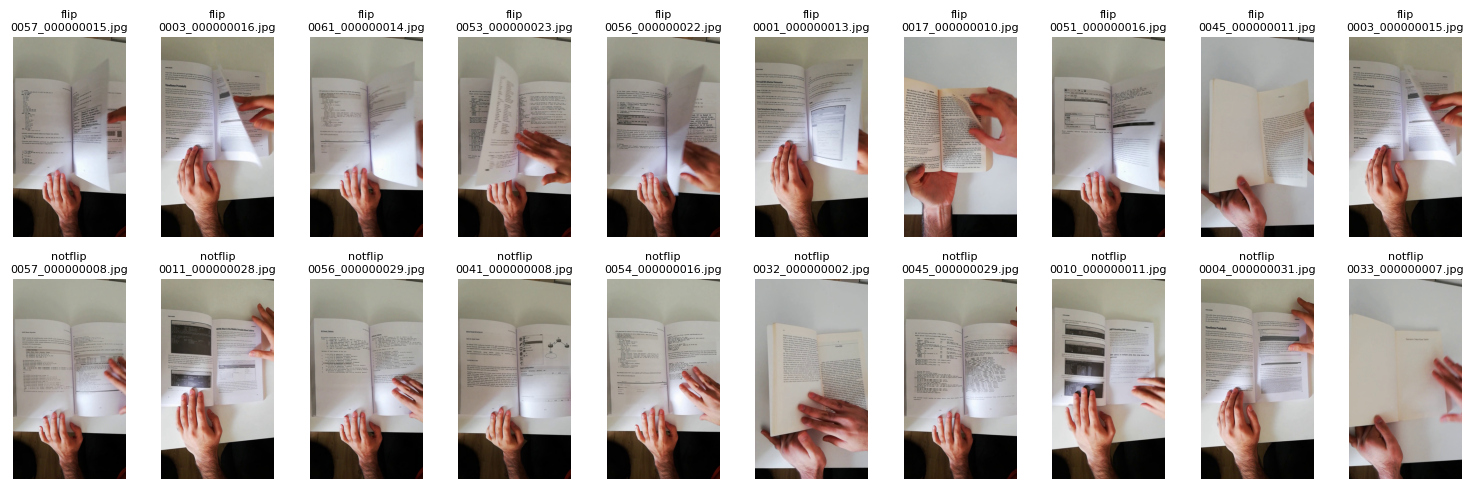

In [118]:
fig, axes = plt.subplots(2, 10, figsize=(15, 5))

for row, classification in enumerate(["flip", "notflip"]):

    folder = f"images/training/{classification}"
    files = random.sample(os.listdir(folder), 10)

    for col, filename in enumerate(files):

        img = Image.open(
            os.path.join(folder, filename)
        ).convert("RGB")

        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{classification}\n{filename}", fontsize=8)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [107]:
# After running several times, the images are very similar in set up. There is a variety of books, but, at least from the repeated checks,
# all flips and not flips are accurately represented.

duplicates = hash_df[
    hash_df.duplicated("hash", keep=False)
].sort_values("hash")

print("These are the duplicates", duplicates)
# There are no duplicates.


train_hashes = set(hash_df.loc[hash_df["dataset"] == "training","hash"])
test_hashes = set(hash_df.loc[hash_df["dataset"] == "testing","hash"])

overlap = train_hashes.intersection(test_hashes)

print("Number of exact duplicates between train and test:", len(overlap))

# There is no overlap between training and testing sets.


These are the duplicates Empty DataFrame
Columns: [dataset, class, filename, path, hash]
Index: []
Number of exact duplicates between train and test: 0


In [108]:
# Naming initial pre-trained model
model = resnet18(weights=weights)

# Ensuring the parameters are not changed using backpropagation for the initial model's layers

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

# Replacing original final layer with a new layer for feature representation to the 2 classes
model.fc = nn.Linear(model.fc.in_features, 2)

for param in model.fc.parameters():
    param.requires_grad = True
print(model.fc)

Linear(in_features=512, out_features=2, bias=True)


In [109]:
indices = np.arange(len(train_dataset))

# Creating a training/validation split to be used while training the model. 
train_idx, val_idx = train_test_split(indices,
    test_size=0.2,
    stratify=train_dataset.targets,
    random_state=42)

# Create the training/validation sets
train_subset = Subset(train_dataset, train_idx)
val_subset = Subset(train_dataset, val_idx)

# Split subsets into batches of 32 for training. 
train_loader = DataLoader(train_subset,batch_size=32,shuffle=True)

val_loader = DataLoader(val_subset,batch_size=32,shuffle=True)

criterion = nn.CrossEntropyLoss()

In [110]:
# AdaM optimizer object to only update model.fc, with conservative learning rate of 0.001. 

optimizer = torch.optim.Adam([
    {"params": model.layer4.parameters(), "lr": 0.0001},
    {"params": model.fc.parameters(), "lr": 0.001}])

# Since running on Mac and Windows, checks for MPS, GPU, or CPU access to optimize batched learning
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# Transfer model to chosen device
model = model.to(device)

print(device)

cpu


In [111]:
# Definining trackers and number of epochs when training
num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_f1s = []
val_f1s = []

best_val_loss = float("inf")
patience = 4
epochs_without_improvement = 0

for epoch in range(num_epochs):

    # Set NN into training mode
    model.train()

    # Initialize running loss and metrics needed to compute accuracy per epoch 
    running_loss = 0
    correct = 0
    total = 0

    train_predictions = []
    train_labels = []

    # For every batch of images with labels in the training loader
    for images, labels in train_loader:

        # Move images and labels to device
        images = images.to(device)
        labels = labels.to(device)

        # Clears old gradients
        optimizer.zero_grad()

        # Pass images through the network; output result
        outputs = model(images)

        # Cross entropy loss computed for outputs
        loss = criterion(outputs, labels)

        # Compute loss gradient
        loss.backward()

        # Changes linear coefficients using AdaM optimizer algorithm
        optimizer.step()

        # Update running loss batch-by-batch
        running_loss += loss.item() * labels.size(0)

        # Column index for output preds
        predictions = outputs.argmax(dim=1)

        train_predictions.extend(predictions.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

        # Update number of correct predictions, only when the preds are the same as the label
        correct += (predictions == labels).sum().item()

        # Updates total considered images
        total += labels.size(0)

    # Calculate training metrics for this epoch
    train_loss = running_loss / total
    train_accuracy = correct / total
    train_f1 = f1_score(train_labels, train_predictions, average="macro")


    # Validation mode for model
    model.eval()

    # Initialize validation tracking variables
    val_loss = 0
    val_correct = 0
    val_total = 0

    val_predictions = []
    val_labels = []

    # Ensures gradients are not saved
    with torch.no_grad():

        # Same process as training set training
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item() * labels.size(0)

            predictions = outputs.argmax(dim=1)

            val_predictions.extend(predictions.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    # Calculate validation metrics for this epoch
    val_loss = val_loss / val_total
    val_accuracy = val_correct / val_total
    val_f1 = f1_score(val_labels, val_predictions, average="macro")

    # Save metrics from THIS epoch
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    train_f1s.append(train_f1)
    val_f1s.append(val_f1)


    # Prints epoch number, train/val loss and train/val accuracy
    print(f"Epoch {epoch + 1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_accuracy:.3f} | "
          f"Train F1: {train_f1:.3f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_accuracy:.3f} | "
          f"Val F1: {val_f1:.3f}")

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        epochs_without_improvement = 0

        torch.save(
            model.state_dict(),
            "best_resnet18_flip_classifier.pth"
        )

        print("Best model saved.")

    else:

        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping.")
        break

model.load_state_dict(
    torch.load(
        "best_resnet18_flip_classifier.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 1/20 | Train Loss: 0.1626 | Train Acc: 0.933 | Train F1: 0.932 | Val Loss: 0.0181 | Val Acc: 0.998 | Val F1: 0.998
Best model saved.
Epoch 2/20 | Train Loss: 0.0108 | Train Acc: 0.997 | Train F1: 0.997 | Val Loss: 0.0479 | Val Acc: 0.987 | Val F1: 0.987
Epoch 3/20 | Train Loss: 0.0038 | Train Acc: 1.000 | Train F1: 1.000 | Val Loss: 0.0189 | Val Acc: 0.996 | Val F1: 0.996
Epoch 4/20 | Train Loss: 0.0109 | Train Acc: 0.997 | Train F1: 0.997 | Val Loss: 0.0182 | Val Acc: 0.996 | Val F1: 0.996
Epoch 5/20 | Train Loss: 0.0049 | Train Acc: 0.998 | Train F1: 0.998 | Val Loss: 0.0243 | Val Acc: 0.996 | Val F1: 0.996
Early stopping.
Best validation loss: 0.0181


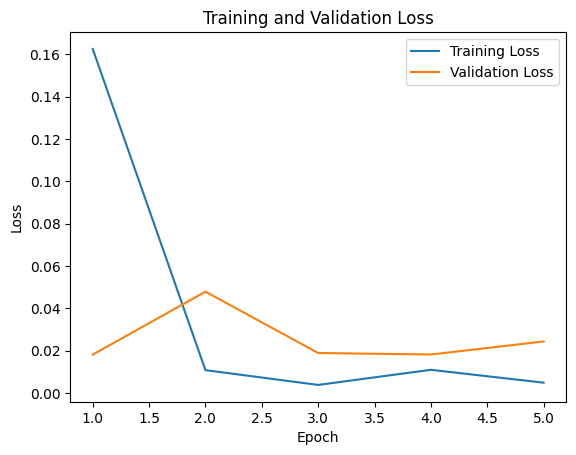

In [114]:
epochs = range(1, len(train_losses) + 1)


## Plotting loss per epoch
plt.figure()

plt.plot(epochs, train_losses, label="Training Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

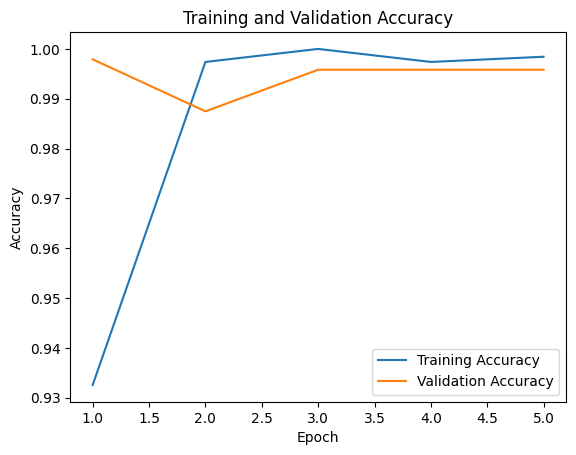

In [115]:
## Plotting accuracy over time
plt.figure()

plt.plot(epochs, train_accuracies, label="Training Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

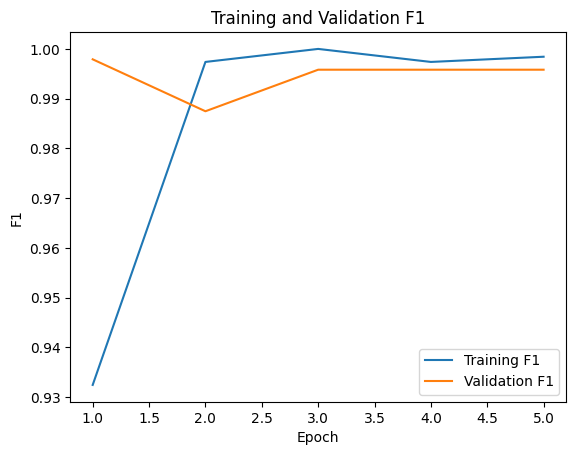

In [116]:
## Plotting F1 over time
plt.figure()

plt.plot(epochs, train_f1s, label="Training F1")
plt.plot(epochs, val_f1s, label="Validation F1")

plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Training and Validation F1")

plt.legend()
plt.show()

In [117]:
all_predictions = []
all_labels = []

print(train_dataset.class_to_idx)
print(test_dataset.class_to_idx)

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes
    )
)

torch.save(
    model.state_dict(),
    "resnet18_flip_classifier.pth"
)

{'flip': 0, 'notflip': 1}
{'flip': 0, 'notflip': 1}
              precision    recall  f1-score   support

        flip       0.99      0.99      0.99       290
     notflip       0.99      0.99      0.99       307

    accuracy                           0.99       597
   macro avg       0.99      0.99      0.99       597
weighted avg       0.99      0.99      0.99       597

